In [ ]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-59f303d1-4f43-4b12-8234-520ccfdfed30)


# Getting data from Tensorflow Dataset

In [ ]:
import tensorflow_datasets as tfds
datasets_list = tfds.list_builders()

In [ ]:
print("food101"in datasets_list)

True


In [ ]:
(train_data, test_data), ds_info = tfds.load(name = 'food101',
                                             split = ['train', 'validation'],
                                             shuffle_files= True,
                                             as_supervised= True, #data gets return in tuple (data,label)
                                             with_info= True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.OJ9CLY_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.OJ9CLY_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


In [ ]:
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [ ]:
class_names = ds_info.features['label'].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [ ]:
for image , label in train_data.take(1):
  print(f'''{image.shape}
{image.dtype}
{label}
{class_names[label.numpy()]}

  ''')

(341, 512, 3)
<dtype: 'uint8'>
98
tiramisu

  


In [ ]:
import tensorflow as tf
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

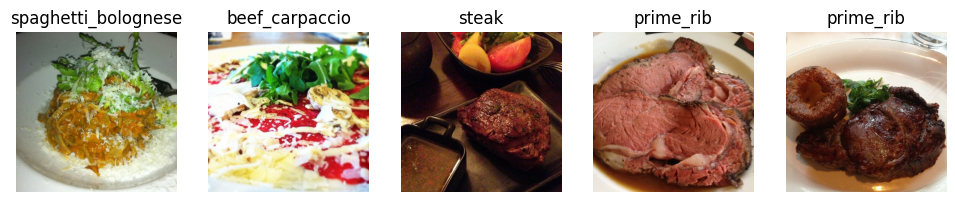

In [ ]:
import matplotlib.pyplot as plt
n=5

plt.figure(figsize=(12,14))

for i,(images, labels) in enumerate(train_data.take(n)):
   plt.subplot(1,n,i+1)
   plt.imshow(images)
   plt.title(f'{class_names[labels.numpy()]}')
   plt.axis('off')

plt.show()


# **Preprocessing Data Function**

In [ ]:
#preprocessing data

def preprocessed_data(image, label, img_size= 224):
   resized_image = tf.image.resize(image, [img_size, img_size])
   float32_image = tf.cast(resized_image, tf.float32)
  #  float32_image = float32_image/255. no need for efficientnet pretrained model
   return float32_image, label

In [ ]:
preprocessed_image = preprocessed_data(image,label)
image, preprocessed_image[0]

(<tf.Tensor: shape=(341, 512, 3), dtype=uint8, numpy=
 array([[[  2,   2,   0],
         [  2,   2,   0],
         [  2,   2,   0],
         ...,
         [  0,   3,   0],
         [  0,   4,   0],
         [  0,   4,   0]],
 
        [[  2,   2,   0],
         [  2,   2,   0],
         [  3,   3,   1],
         ...,
         [  1,   3,   0],
         [  0,   4,   0],
         [  0,   4,   0]],
 
        [[  5,   6,   1],
         [  5,   6,   1],
         [  5,   6,   1],
         ...,
         [  1,   3,   0],
         [  0,   4,   0],
         [  0,   5,   1]],
 
        ...,
 
        [[143,  75,  10],
         [149,  81,  16],
         [150,  85,  19],
         ...,
         [162,  88,  25],
         [150,  79,  17],
         [135,  65,   5]],
 
        [[144,  76,  11],
         [152,  84,  19],
         [145,  80,  16],
         ...,
         [126,  60,  12],
         [111,  50,   3],
         [ 95,  37,   0]],
 
        [[145,  77,  14],
         [150,  82,  19],
         [139,

In [ ]:
#applying on all data using map

train_data = train_data.map(map_func= preprocessed_data, num_parallel_calls= tf.data.AUTOTUNE)
train_data = train_data.shuffle(buffer_size= 1000).batch(batch_size= 32).prefetch(buffer_size= tf.data.AUTOTUNE)
test_data = test_data.map(map_func= preprocessed_data, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(buffer_size= tf.data.AUTOTUNE)

In [ ]:
checkpoint_path = "model_checkpoint/cp.weights.h5"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                      monitor= 'val_accuracy',
                                                      save_best_only= True,
                                                      save_weights_only=True,
                                                      verbose= 0)

#**Setup Mixed Precision Training**
mixed precision training utilizes the float16 and float32 datatypes to speed up model performance

In [ ]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [ ]:
mixed_precision.global_policy()

<DTypePolicy "mixed_float16">

In [ ]:
input_shape = (224,224,3)

base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

inputs = tf.keras.Input(shape = input_shape, name= 'input_layer')

x = base_model(inputs, training= False)

x = tf.keras.layers.GlobalAveragePooling2D(name= 'global_poolin_layer')(x)

x = tf.keras.layers.Dense(len(class_names), name= 'Dense_layer')(x)

outputs = tf.keras.layers.Activation('softmax', dtype= 'float32', name= 'softmax_float32')(x)

model = tf.keras.Model(inputs,outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_poolin_layer             │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_layer (Dense)             │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_1 (Cast)                   │ (None, 101)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Compile the model
model.compile(loss="sparse_categorical_crossentropy", # Use sparse_categorical_crossentropy when labels are *not* one-hot
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

**layer.dtype** - datatype of variables layer **stores**

**layer.dtype_policy** - datatype of variables on which **layer computes**

In [ ]:
for i,layer in enumerate(model.layers):
  print(i,layer.name,layer.trainable, layer.dtype, layer.dtype_policy)

0 input_layer True float32 <DTypePolicy "mixed_float16">
1 efficientnetb0 False float32 <DTypePolicy "mixed_float16">
2 global_poolin_layer True float32 <DTypePolicy "mixed_float16">
3 Dense_layer True float32 <DTypePolicy "mixed_float16">
4 softmax_float32 True float32 <DTypePolicy "float32">


In [ ]:
d = {}
l1=[]
l2=[]
l3=[]
l4=[]
for layer in model.layers:
  l1.append(layer.name)
  l2.append(layer.trainable)
  l3.append(layer.dtype)
  l4.append(layer.dtype_policy)
d['layer_name'] = l1
d['trainable'] = l2
d['layer_type'] = l3
d['layer_type_policy'] = l4
import pandas as pd
df = pd.DataFrame(d)
df

,layer_name,trainable,layer_type,layer_type_policy
0,input_layer,True,float32,"<DTypePolicy ""mixed_float16"">"
1,efficientnetb0,False,float32,"<DTypePolicy ""mixed_float16"">"
2,global_poolin_layer,True,float32,"<DTypePolicy ""mixed_float16"">"
3,Dense_layer,True,float32,"<DTypePolicy ""mixed_float16"">"
4,softmax_float32,True,float32,"<DTypePolicy ""float32"">"


In [ ]:
d0 = {}
l1=[]
l2=[]
l3=[]
l4=[]
for layer in base_model.layers:
  l1.append(layer.name)
  l2.append(layer.trainable)
  l3.append(layer.dtype)
  l4.append(layer.dtype_policy)
d0['layer_name'] = l1
d0['trainable'] = l2
d0['layer_type'] = l3
d0['layer_type_policy'] = l4
import pandas as pd
df = pd.DataFrame(d0)
df

,layer_name,trainable,layer_type,layer_type_policy
0,input_layer,False,float32,"<DTypePolicy ""mixed_float16"">"
1,rescaling,False,float32,"<DTypePolicy ""mixed_float16"">"
2,normalization,False,float32,"<DTypePolicy ""mixed_float16"">"
3,rescaling_1,False,float32,"<DTypePolicy ""mixed_float16"">"
4,stem_conv_pad,False,float32,"<DTypePolicy ""mixed_float16"">"
...,...,...,...,...
233,block7a_project_conv,False,float32,"<DTypePolicy ""mixed_float16"">"
234,block7a_project_bn,False,float32,"<DTypePolicy ""mixed_float16"">"
235,top_conv,False,float32,"<DTypePolicy ""mixed_float16"">"
236,top_bn,False,float32,"<DTypePolicy ""mixed_float16"">"


In [ ]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2025-06-12 12:51:34--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0.001s  

2025-06-12 12:51:35 (7.70 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [ ]:
from helper_functions import plot_loss_curves,compare_historys, create_tensorboard_callback

In [ ]:
history = model.fit(train_data,
          epochs = 5,
          steps_per_epoch = len(train_data),
          validation_data= test_data,
          validation_steps= int(0.15*len(test_data)),
          callbacks = [create_tensorboard_callback('tensorboard_callback', 'feature_extract_model'), model_checkpoint])

Saving TensorBoard log files to: tensorboard_callback/feature_extract_model/20250612-135318
Epoch 1/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 154s 64ms/step - accuracy: 0.7745 - loss: 0.8370 - val_accuracy: 0.7344 - val_loss: 0.9642
Epoch 2/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 202s 64ms/step - accuracy: 0.7781 - loss: 0.8159 - val_accuracy: 0.7352 - val_loss: 0.9653
Epoch 3/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 152s 63ms/step - accuracy: 0.7875 - loss: 0.7844 - val_accuracy: 0.7373 - val_loss: 0.9690
Epoch 4/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 200s 63ms/step - accuracy: 0.7957 - loss: 0.7577 - val_accuracy: 0.7323 - val_loss: 0.9891
Epoch 5/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 151s 63ms/step - accuracy: 0.7968 - loss: 0.7473 - val_accuracy: 0.7331 - val_loss: 0.9865


In [ ]:
results_feature_extract_model = model.evaluate(test_data)
results_feature_extract_model

790/790 ━━━━━━━━━━━━━━━━━━━━ 43s 54ms/step - accuracy: 0.7322 - loss: 0.9916


[0.9862046837806702, 0.7352079153060913]

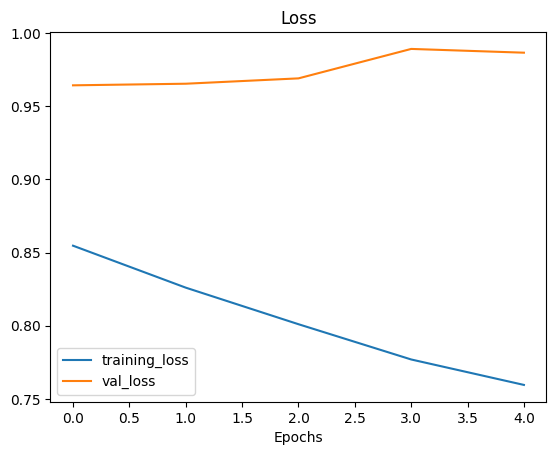

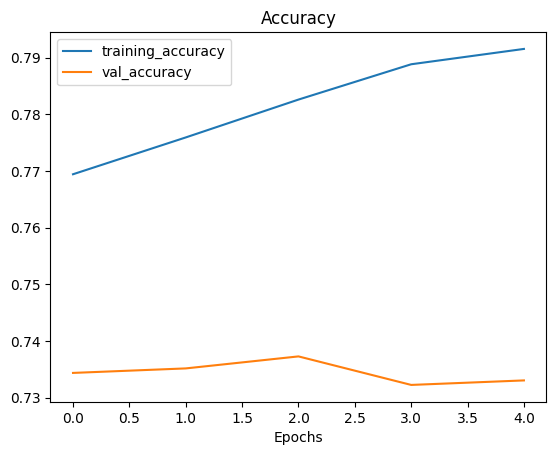

In [ ]:
plot_loss_curves(history)

# Checking Checkpoints works well or not

In [ ]:
clone_model = tf.keras.models.clone_model(model)
clone_model.compile(loss="sparse_categorical_crossentropy", # Use sparse_categorical_crossentropy when labels are *not* one-hot
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

In [ ]:
import os
print(os.path.exists('model_checkpoint/cp.weights.h5'))


True


In [ ]:
clone_model.load_weights(checkpoint_path)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
results_clone_model = clone_model.evaluate(test_data)
results_clone_model

790/790 ━━━━━━━━━━━━━━━━━━━━ 57s 59ms/step - accuracy: 0.7335 - loss: 0.9677


[0.9648107290267944, 0.7362772226333618]

In [ ]:
import numpy as np
np.isclose(results_clone_model,results_feature_extract_model).all()

np.False_

In [ ]:
# Check the layers in the base model and see what dtype policy they're using
for layer in clone_model.layers[1].layers[:20]: # check only the first 20 layers to save printing space
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer True float32 <DTypePolicy "mixed_float16">
rescaling False float32 <DTypePolicy "mixed_float16">
normalization False float32 <DTypePolicy "mixed_float16">
rescaling_1 False float32 <DTypePolicy "mixed_float16">
stem_conv_pad False float32 <DTypePolicy "mixed_float16">
stem_conv False float32 <DTypePolicy "mixed_float16">
stem_bn False float32 <DTypePolicy "mixed_float16">
stem_activation False float32 <DTypePolicy "mixed_float16">
block1a_dwconv False float32 <DTypePolicy "mixed_float16">
block1a_bn False float32 <DTypePolicy "mixed_float16">
block1a_activation False float32 <DTypePolicy "mixed_float16">
block1a_se_squeeze False float32 <DTypePolicy "mixed_float16">
block1a_se_reshape False float32 <DTypePolicy "mixed_float16">
block1a_se_reduce False float32 <DTypePolicy "mixed_float16">
block1a_se_expand False float32 <DTypePolicy "mixed_float16">
block1a_se_excite False float32 <DTypePolicy "mixed_float16">
block1a_project_conv False float32 <DTypePolicy "mixed_float16">

In [ ]:
save_dir ='drive/MyDrive/Food_classification_model'
#making directory
os.makedirs(save_dir)

In [ ]:
model.save('drive/MyDrive/Food_classification_model/food_classification_model.keras')

In [ ]:
loaded_model = tf.keras.models.load_model('drive/MyDrive/Food_classification_model/food_classification_model.keras')

In [ ]:
results_loaded_model= loaded_model.evaluate(test_data)
results_loaded_model

790/790 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - accuracy: 0.7318 - loss: 0.9923


[0.9862053394317627, 0.7352079153060913]

In [ ]:
np.isclose(results_feature_extract_model, results_loaded_model)

array([ True,  True])

In [ ]:
loaded_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_poolin_layer             │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_layer (Dense)             │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_14 (Cast)                  │ (None, 101)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,437,720 (16.93 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 258,768 (1010.82 KB)

In [ ]:
for layer in loaded_model.layers:
  layer.trainable = True
  print(layer.name,layer.trainable)

input_layer True
efficientnetb0 True
global_poolin_layer True
Dense_layer True
softmax_float32 True


In [ ]:
# Check the layers in the base model retains dtype policy (we want to be "mixed_float16")
for layer in loaded_model.layers[1].layers[:20]: # check only the first 20 layers to save output space
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer True float32 <DTypePolicy "mixed_float16">
rescaling True float32 <DTypePolicy "mixed_float16">
normalization True float32 <DTypePolicy "mixed_float16">
rescaling_1 True float32 <DTypePolicy "mixed_float16">
stem_conv_pad True float32 <DTypePolicy "mixed_float16">
stem_conv True float32 <DTypePolicy "mixed_float16">
stem_bn True float32 <DTypePolicy "mixed_float16">
stem_activation True float32 <DTypePolicy "mixed_float16">
block1a_dwconv True float32 <DTypePolicy "mixed_float16">
block1a_bn True float32 <DTypePolicy "mixed_float16">
block1a_activation True float32 <DTypePolicy "mixed_float16">
block1a_se_squeeze True float32 <DTypePolicy "mixed_float16">
block1a_se_reshape True float32 <DTypePolicy "mixed_float16">
block1a_se_reduce True float32 <DTypePolicy "mixed_float16">
block1a_se_expand True float32 <DTypePolicy "mixed_float16">
block1a_se_excite True float32 <DTypePolicy "mixed_float16">
block1a_project_conv True float32 <DTypePolicy "mixed_float16">
block1a_project

For small amount of images we freeze -- less layers

For this model we unfreeze all layers -- bcoz hving 75750 images

In [ ]:
loaded_model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
                     optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
                     metrics= ['accuracy'])

In [ ]:
history_fine_tune_model = loaded_model.fit(train_data,
                                           epochs = 10,
                                           steps_per_epoch = len(train_data),
                                           validation_data = test_data,
                                           validation_steps = int(0.15*len(test_data)),
                                           initial_epoch = 5,
                                          #  callbacks = [create_tensorboard_callback('tensorboard_callback','fine_tune_model')]
)

Epoch 6/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 271s 113ms/step - accuracy: 0.5971 - loss: 1.6038 - val_accuracy: 0.7741 - val_loss: 0.8043
Epoch 7/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 256s 86ms/step - accuracy: 0.8124 - loss: 0.6763 - val_accuracy: 0.7905 - val_loss: 0.7516
Epoch 8/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 228s 95ms/step - accuracy: 0.8782 - loss: 0.4380 - val_accuracy: 0.8003 - val_loss: 0.7192
Epoch 9/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 217s 91ms/step - accuracy: 0.9117 - loss: 0.3139 - val_accuracy: 0.8104 - val_loss: 0.7142
Epoch 10/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 261s 90ms/step - accuracy: 0.9431 - loss: 0.2159 - val_accuracy: 0.8003 - val_loss: 0.7544


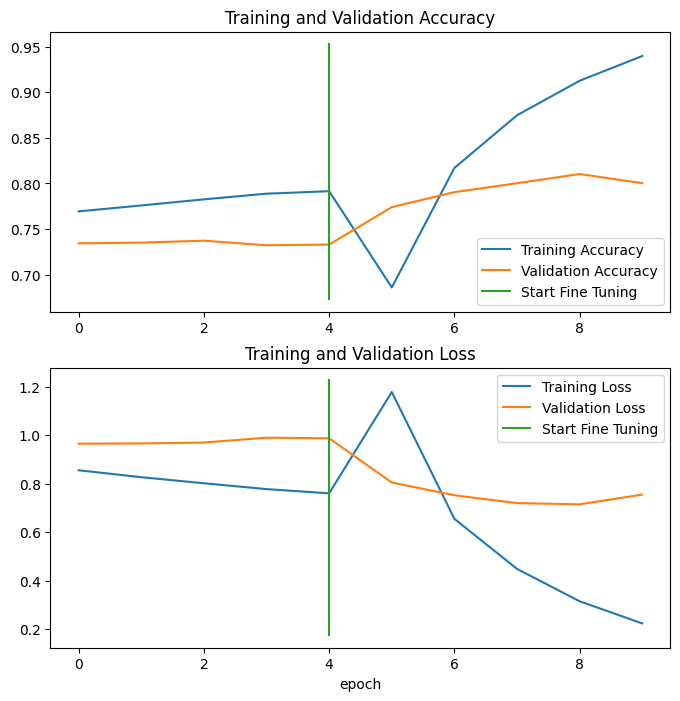

In [ ]:
compare_historys(history, history_fine_tune_model)

In [ ]:
history_fine_tune_model = loaded_model.fit(train_data,
                                           epochs = 10,
                                           steps_per_epoch = len(train_data),
                                           validation_data = test_data,
                                           validation_steps = int(0.15*len(test_data)),
                                           initial_epoch = history.epoch[-1],
                                           callbacks = [create_tensorboard_callback('tensorboard_callback','fine_tune_model')])

Saving TensorBoard log files to: tensorboard_callback/fine_tune_model/20250612-152040
Epoch 5/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 217s 91ms/step - accuracy: 0.9593 - loss: 0.1573 - val_accuracy: 0.8099 - val_loss: 0.7570
Epoch 6/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 213s 89ms/step - accuracy: 0.9672 - loss: 0.1258 - val_accuracy: 0.8151 - val_loss: 0.7560
Epoch 7/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 215s 89ms/step - accuracy: 0.9723 - loss: 0.1049 - val_accuracy: 0.8149 - val_loss: 0.7440
Epoch 8/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 262s 110ms/step - accuracy: 0.9770 - loss: 0.0879 - val_accuracy: 0.8109 - val_loss: 0.7651
Epoch 9/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 212s 88ms/step - accuracy: 0.9816 - loss: 0.0749 - val_accuracy: 0.8189 - val_loss: 0.7574
Epoch 10/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 265s 90ms/step - accuracy: 0.9833 - loss: 0.0664 - val_accuracy: 0.8159 - val_loss: 0.7931


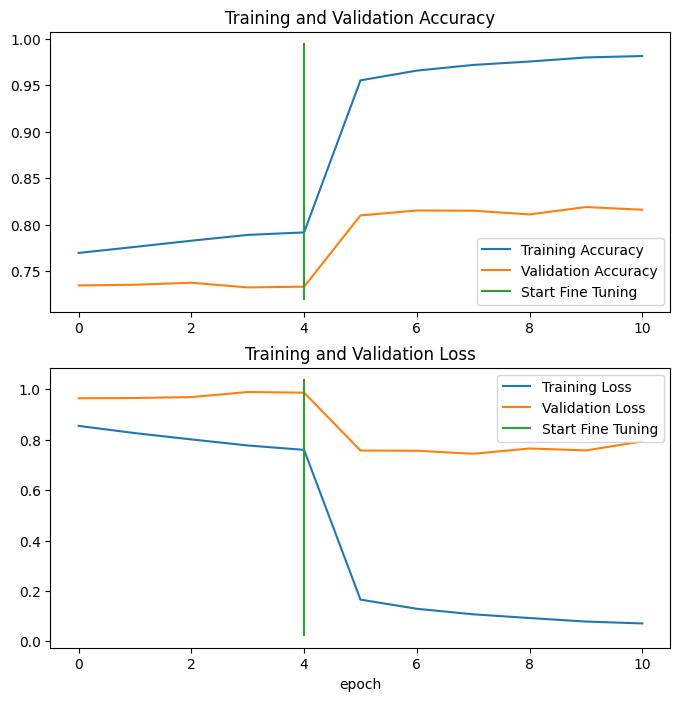

In [ ]:
compare_historys(history, history_fine_tune_model)

In [ ]:
loaded_model.save('drive/MyDrive/Food_classification_model/fine_tune_model.keras')

In [ ]:
loaded_fine_tun_model = tf.keras.models.load_model('drive/MyDrive/Food_classification_model/fine_tune_model.keras')
results_loaded_fine_tun_model = loaded_fine_tun_model.evaluate(test_data)


790/790 ━━━━━━━━━━━━━━━━━━━━ 63s 64ms/step - accuracy: 0.8149 - loss: 0.7982


In [ ]:
results_loaded_fine_tun_model

[0.807261049747467, 0.8143366575241089]